# **R ANALYTICS**

## **1. Install and load packages**

In [27]:
# Install packages
install.packages("ggplot2", quiet = TRUE)
install.packages("sqldf", quiet = TRUE)
install.packages("corrplot", quiet = TRUE)

# Load libraries
library(ggplot2)
library(sqldf)
library(corrplot)

print("Packages loaded")

[1] "Packages loaded"


## **2. Load the cleaned CSVs**

In [28]:
# Load each cleaned CSV
deliveries <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/deliveries_clean.csv", stringsAsFactors = FALSE)
orders     <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/orders_clean.csv",     stringsAsFactors = FALSE)
drivers    <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/drivers_clean.csv",    stringsAsFactors = FALSE)
complaints <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/complaints_clean.csv", stringsAsFactors = FALSE)
hubs       <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/hubs_clean.csv",       stringsAsFactors = FALSE)
vehicles   <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/vehicles_clean.csv",   stringsAsFactors = FALSE)
incidents  <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/incidents_clean.csv",  stringsAsFactors = FALSE)
customers  <- read.csv("https://raw.githubusercontent.com/Habishalini/NorthStar-Database_Analytics-Coursework/refs/heads/main/Cleaned%20Datasets/customers_clean.csv",  stringsAsFactors = FALSE)

# Confirm row counts
cat("deliveries:", nrow(deliveries), "rows\n")
cat("orders:    ", nrow(orders),     "rows\n")
cat("drivers:   ", nrow(drivers),    "rows\n")
cat("complaints:", nrow(complaints), "rows\n")
cat("hubs:      ", nrow(hubs),       "rows\n")
cat("vehicles:  ", nrow(vehicles),   "rows\n")
cat("incidents: ", nrow(incidents),  "rows\n")
cat("customers: ", nrow(customers),  "rows\n")

deliveries: 950 rows
orders:     1250 rows
drivers:    170 rows
complaints: 320 rows
hubs:       8 rows
vehicles:   120 rows
incidents:  280 rows
customers:  650 rows


## **3. Chart 1 - Delivery status by zone (grouped bar)**

   pickup_zone delivery_status count
1      Airport         Delayed    31
2      Airport          Failed    12
3      Airport          OnTime    70
4      Central         Delayed    51
5      Central          Failed    33
6      Central          OnTime    90
7         East         Delayed    31
8         East          Failed    19
9         East          OnTime   106
10       North         Delayed    21
11       North          Failed    22
12       North          OnTime    92
13   Riverside         Delayed    25
14   Riverside          Failed    18
15   Riverside          OnTime    76
16       South         Delayed    22
17       South          Failed    14
18       South          OnTime   103
19        West         Delayed    21
20        West          Failed    14
21        West          OnTime    79


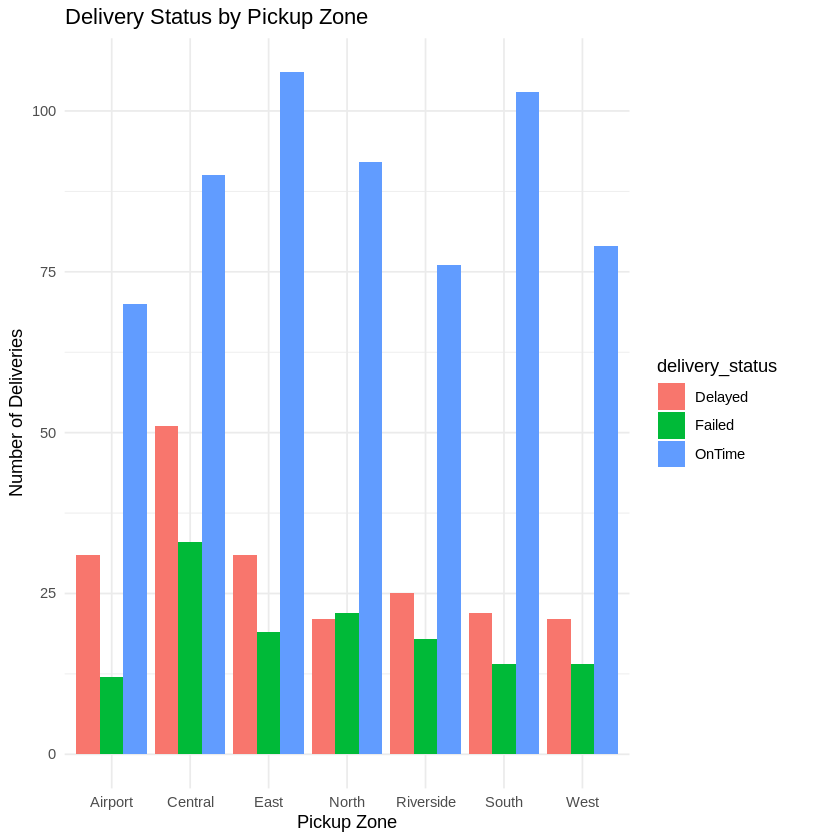

In [29]:
# Summarise the data using SQL
status_data <- sqldf("
SELECT
  pickup_zone,
  delivery_status,
  COUNT(*) AS count
FROM deliveries
JOIN orders ON deliveries.order_id = orders.order_id
GROUP BY pickup_zone, delivery_status
")

print(status_data)

# Now plot it with ggplot2
ggplot(status_data, aes(x = pickup_zone, y = count, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Delivery Status by Pickup Zone",
       x = "Pickup Zone",
       y = "Number of Deliveries") +
  theme_minimal()

## **4. Chart 2 - Histogram of driver ratings**

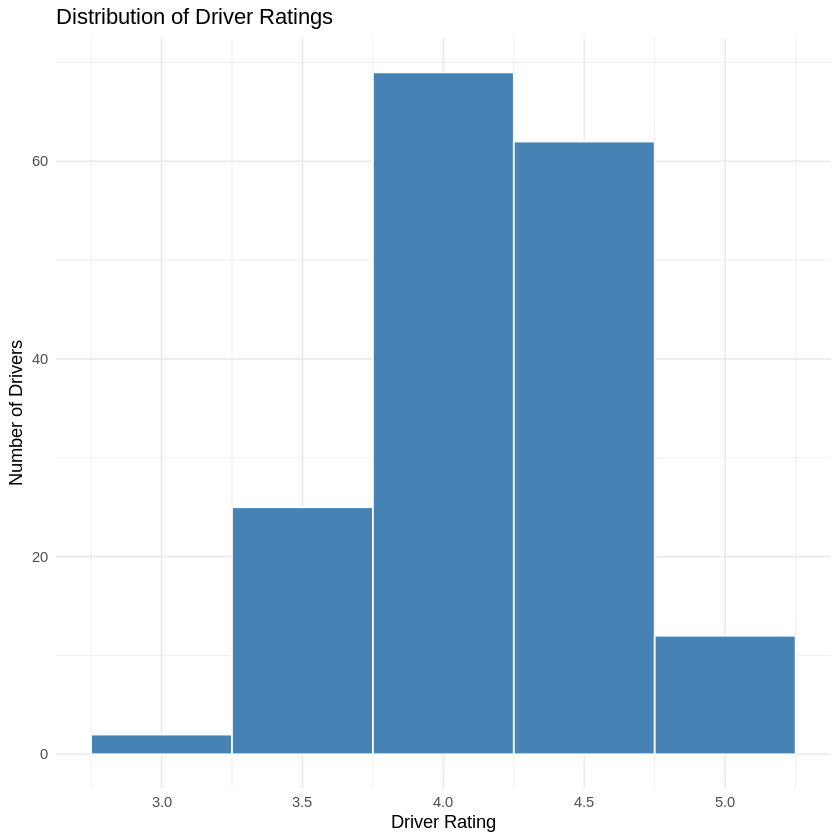

In [30]:
# Show how driver ratings are distributed across all drivers

ggplot(drivers, aes(x = driver_rating)) +
  geom_histogram(binwidth = 0.5, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Driver Ratings",
       x = "Driver Rating",
       y = "Number of Drivers") +
  theme_minimal()

## **5. Chart 3 - Experience vs rating**

`geom_smooth()` using formula = 'y ~ x'


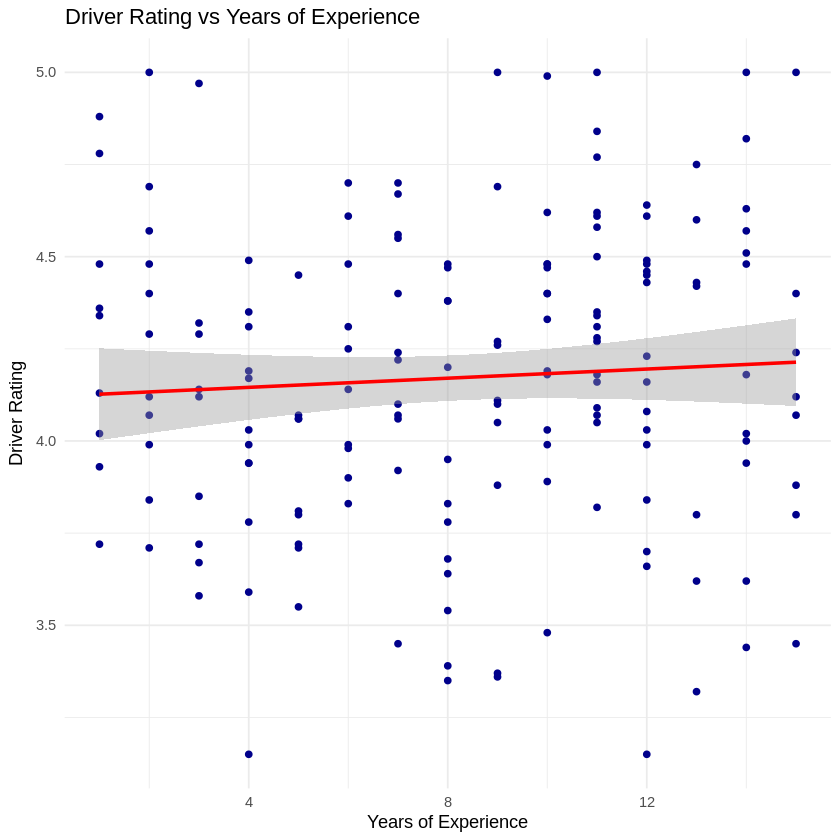

In [31]:
# Check more experience mean a higher rating

ggplot(drivers, aes(x = years_experience, y = driver_rating)) +
  geom_point(color = "darkblue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Driver Rating vs Years of Experience",
       x = "Years of Experience",
       y = "Driver Rating") +
  theme_minimal()

## **6. Chart 4 - Battery health by maintenance status**

  maintenance_status average_battery
1             Active           76.64
2           InRepair           76.64
3          Scheduled           77.67


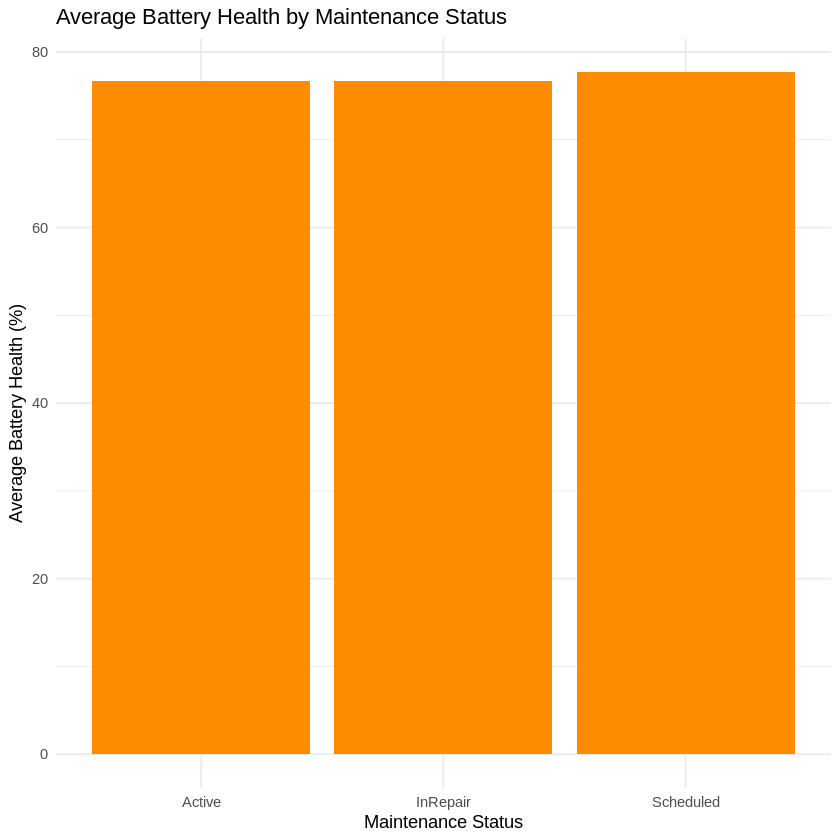

In [32]:
# Summarise with SQL
battery_data <- sqldf("
SELECT
  maintenance_status,
  ROUND(AVG(battery_health_pct), 2) AS average_battery
FROM vehicles
GROUP BY maintenance_status
ORDER BY average_battery ASC
")

print(battery_data)

# Now plot
ggplot(battery_data, aes(x = maintenance_status, y = average_battery)) +
  geom_bar(stat = "identity", fill = "darkorange") +
  labs(title = "Average Battery Health by Maintenance Status",
       x = "Maintenance Status",
       y = "Average Battery Health (%)") +
  theme_minimal()

## **7. Chart 5 - Complaint resolution by severity**

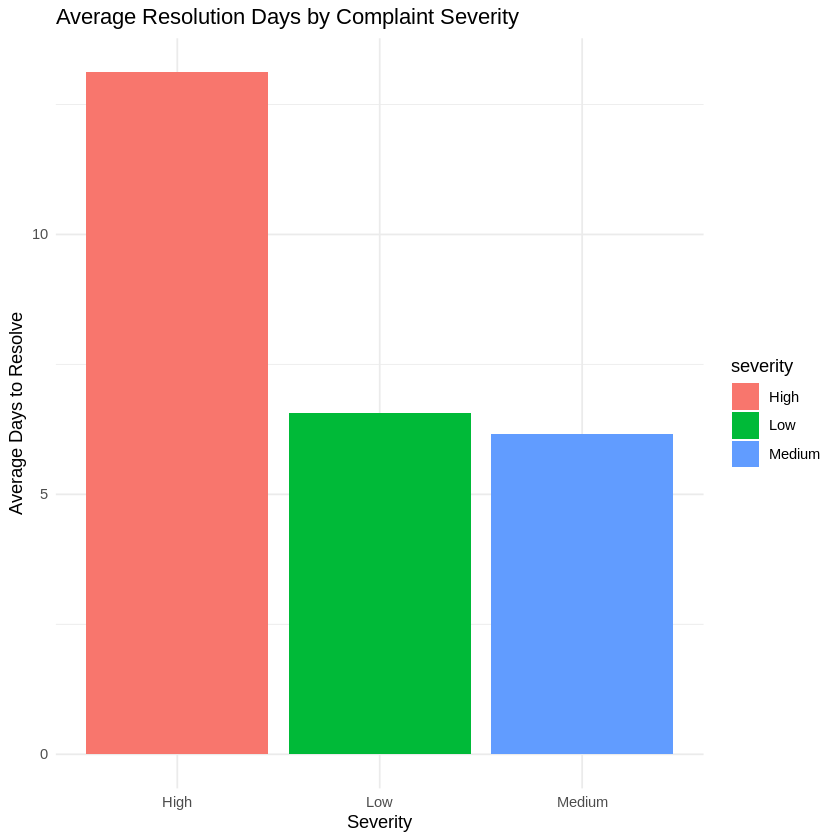

In [33]:
# Check average days to resolve complaints, grouped by severity

ggplot(complaints, aes(x = severity, y = resolution_days, fill = severity)) +
  geom_bar(stat = "summary", fun = "mean") +
  labs(title = "Average Resolution Days by Complaint Severity",
       x = "Severity",
       y = "Average Days to Resolve") +
  theme_minimal()

## **8. Descriptive statistics**

In [34]:
# Get basic statistics for the numeric columns in deliveries
print("Statistics for key delivery columns:")
summary(deliveries[, c("route_distance_km",
                       "manual_route_override_count",
                       "customer_rating_post_delivery",
                       "fuel_or_charge_cost")])

[1] "Statistics for key delivery columns:"


 route_distance_km manual_route_override_count customer_rating_post_delivery
 Min.   : 1.200    Min.   :0.0000              Min.   :1.000                
 1st Qu.: 9.135    1st Qu.:0.0000              1st Qu.:3.373                
 Median :12.840    Median :1.0000              Median :4.030                
 Mean   :13.909    Mean   :0.9695              Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :41.940    Max.   :7.0000              Max.   :5.000                
 fuel_or_charge_cost
 Min.   : 2.500     
 1st Qu.: 9.925     
 Median :12.645     
 Mean   :12.841     
 3rd Qu.:15.697     
 Max.   :29.430     

## **9. Correlation between numeric variables**

In [35]:
# Pick only the numeric columns we want to compare
my_numbers <- deliveries[, c("route_distance_km",
                             "manual_route_override_count",
                             "customer_rating_post_delivery",
                             "fuel_or_charge_cost")]

# Calculate correlation
my_correlation <- cor(my_numbers)

# Round to 2 decimals and print
print(round(my_correlation, 2))

                              route_distance_km manual_route_override_count
route_distance_km                          1.00                        0.20
manual_route_override_count                0.20                        1.00
customer_rating_post_delivery              0.03                       -0.06
fuel_or_charge_cost                        0.52                        0.10
                              customer_rating_post_delivery fuel_or_charge_cost
route_distance_km                                      0.03                0.52
manual_route_override_count                           -0.06                0.10
customer_rating_post_delivery                          1.00               -0.06
fuel_or_charge_cost                                   -0.06                1.00


## **10. Correlation heatmap**

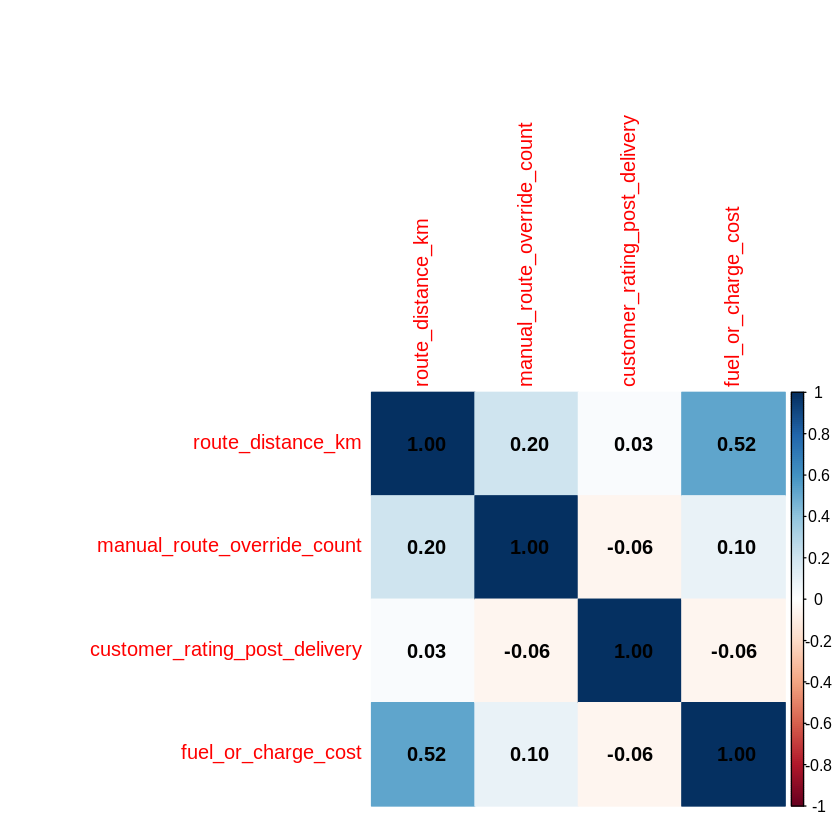

In [36]:
# Draw the correlation as a coloured heatmap
corrplot(my_correlation, method = "color", addCoef.col = "black")

# **11. T-test: do overrides cause failures?**

In [37]:
# Do failed deliveries have MORE route overrides than on-time ones?

# Get override counts for failed deliveries
failed_overrides <- deliveries$manual_route_override_count[deliveries$delivery_status == "Failed"]

# Get override counts for on-time deliveries
ontime_overrides <- deliveries$manual_route_override_count[deliveries$delivery_status == "OnTime"]

# Print the averages
print("Average overrides on Failed deliveries:")
print(mean(failed_overrides))

print("Average overrides on OnTime deliveries:")
print(mean(ontime_overrides))

# Run the t-test
my_test <- t.test(failed_overrides, ontime_overrides)
print(my_test)

[1] "Average overrides on Failed deliveries:"
[1] 1.037879
[1] "Average overrides on OnTime deliveries:"
[1] 0.9204545

	Welch Two Sample t-test

data:  failed_overrides and ontime_overrides
t = 1.1926, df = 200.03, p-value = 0.2344
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.07672771  0.31157619
sample estimates:
mean of x mean of y 
1.0378788 0.9204545 



## **12. Chi-square test: are some hubs more failure-prone?**

In [38]:
# Question: Are some hubs more likely to fail than others, or is it random?

# Build a table: rows = hubs, columns = statuses
my_table <- table(deliveries$hub_id, deliveries$delivery_status)
print(my_table)

# Run the chi-square test
chi_test <- chisq.test(my_table)
print(chi_test)

     
      Delayed Failed OnTime
  H01      26     17     93
  H02      26     10     70
  H03      23     11     85
  H04      28     16     83
  H05      25     23     67
  H06      27     15     62
  H07      25     14     76
  H08      22     26     80

	Pearson's Chi-squared test

data:  my_table
X-squared = 16.466, df = 14, p-value = 0.2858



## **13. Final summary**

In [39]:
# Print a summary of the main findings

print("=== KEY FINDINGS FROM ANALYSIS ===")

print("Driver ratings:")
print("Average rating:")
print(round(mean(drivers$driver_rating), 2))

print("Number of drivers below 3.5 rating:")
print(sum(drivers$driver_rating < 3.5))

print("Average days to resolve High severity complaints:")
high_severity <- complaints$resolution_days[complaints$severity == "High"]
print(round(mean(high_severity), 2))

print("Average days to resolve Low severity complaints:")
low_severity <- complaints$resolution_days[complaints$severity == "Low"]
print(round(mean(low_severity), 2))

[1] "=== KEY FINDINGS FROM ANALYSIS ==="
[1] "Driver ratings:"
[1] "Average rating:"
[1] 4.17
[1] "Number of drivers below 3.5 rating:"
[1] 11
[1] "Average days to resolve High severity complaints:"
[1] 13.12
[1] "Average days to resolve Low severity complaints:"
[1] 6.56
